In [ ]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Vérification de l'activation du GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("--- Statut de l'environnement ---")
print(f"PyTorch version : {torch.__version__}")
print(f"L'appareil utilisé pour les calculs est : {device}")

if device.type == 'cuda':
    print(f"Nom du GPU : {torch.cuda.get_device_name(0)}")
else:
    print("ATTENTION : Le GPU n'est pas activé. Les calculs seront très lents.")

--- Statut de l'environnement ---
PyTorch version : 2.10.0+cu128
L'appareil utilisé pour les calculs est : cuda
Nom du GPU : Tesla T4


In [4]:
import os

# 1. Définition du chemin principal vers le dataset
dataset_path = '/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD'

# 2. On définit les chemins vers les 3 sous-dossiers : 
# Training (pour apprendre), Development (pour valider pendant l'apprentissage), Evaluation (pour le test final)
train_dir = os.path.join(dataset_path, 'LCC_FASD_training')
val_dir = os.path.join(dataset_path, 'LCC_FASD_development')
test_dir = os.path.join(dataset_path, 'LCC_FASD_evaluation')

# 3. Petite fonction pratique pour compter le nombre d'images par classe (réel vs spoof)
def count_images(directory):
    if not os.path.exists(directory):
        return "Dossier introuvable (Vérifiez le chemin !)"
    
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

# 4. Affichage des résultats
print("--- Analyse du contenu du Dataset LCC FASD ---")
print(f"Dossier d'entraînement (Train) : {count_images(train_dir)}")
print(f"Dossier de validation (Dev) : {count_images(val_dir)}")
print(f"Dossier de test (Eval) : {count_images(test_dir)}")

--- Analyse du contenu du Dataset LCC FASD ---
Dossier d'entraînement (Train) : {'spoof': 7076, 'real': 1223}
Dossier de validation (Dev) : {'spoof': 2543, 'real': 405}
Dossier de test (Eval) : {'spoof': 7266, 'real': 314}


In [5]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt

print("--- Préparation du Data Pipeline ---")

# 1. Les "Transformations" : On met les images au format attendu par le Swin Transformer
# On ajoute une petite Data Augmentation (RandomHorizontalFlip) pour le train
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Retourne l'image aléatoirement comme un miroir
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet
])

transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Chargement des dossiers avec ImageFolder
train_dataset = ImageFolder(root=train_dir, transform=transform_train)
val_dataset = ImageFolder(root=val_dir, transform=transform_val_test)
test_dataset = ImageFolder(root=test_dir, transform=transform_val_test)

# 3. GESTION DU DÉSÉQUILIBRE (Le cœur de la stratégie)
# On calcule le poids de chaque classe (plus une classe est rare, plus son poids est fort)
class_counts = [1223, 7076] # [real, spoof] 
class_weights = [1.0 / count for count in class_counts]

# On attribue le poids correspondant à chaque image du dataset d'entraînement
sample_weights = [class_weights[label] for _, label in train_dataset]

# Le "Sampler" va utiliser ces poids pour piocher les images de façon équilibrée
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_dataset), replacement=True)

# 4. Création des DataLoaders (les camions de livraison d'images vers l'IA)
batch_size = 32 # On donne les images par paquets de 32 à l'IA
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Classes détectées par PyTorch : {train_dataset.classes}")
print(f"Nombre de paquets (batches) pour l'entraînement : {len(train_loader)}")
print("Le pipeline est prêt et équilibré !")

--- Préparation du Data Pipeline ---
Classes détectées par PyTorch : ['real', 'spoof']
Nombre de paquets (batches) pour l'entraînement : 260
Le pipeline est prêt et équilibré !


--- Inspection visuelle du Dataset ---


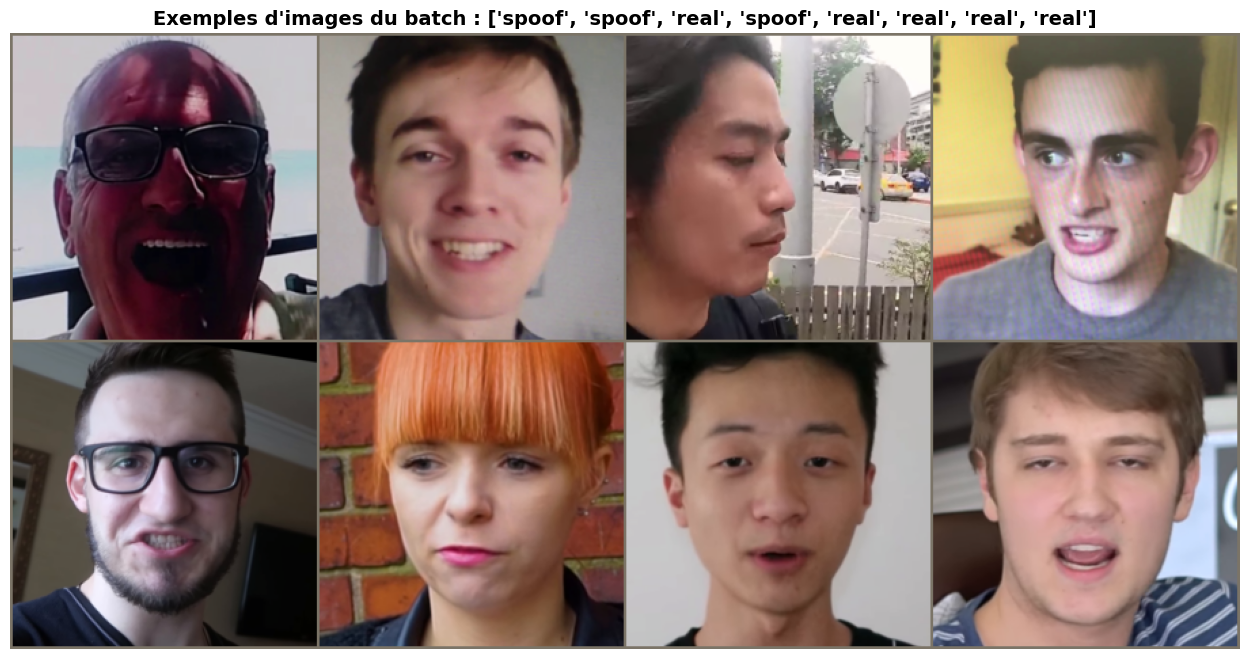

In [6]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

print("--- Inspection visuelle du Dataset ---")

# Fonction pour "dé-normaliser" et afficher les images correctement
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # On remet les couleurs d'origine (inverse de la normalisation ImageNet)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # S'assure que les valeurs des pixels restent entre 0 et 1
    
    plt.figure(figsize=(16, 8))
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# On demande à notre "train_loader" de nous livrer 1 seul paquet (batch) d'images
images, labels = next(iter(train_loader))
class_names = train_dataset.classes

# On prend seulement les 8 premières images du paquet pour que ce soit lisible
images_to_show = images[:8]
labels_to_show = labels[:8]

# On crée une grille avec ces 8 images
grid = torchvision.utils.make_grid(images_to_show, nrow=4)

# On prépare les titres (Real ou Spoof) pour chaque image
titres = [class_names[x] for x in labels_to_show]

# On affiche la grille !
imshow(grid, title=f"Exemples d'images du batch : {titres}")

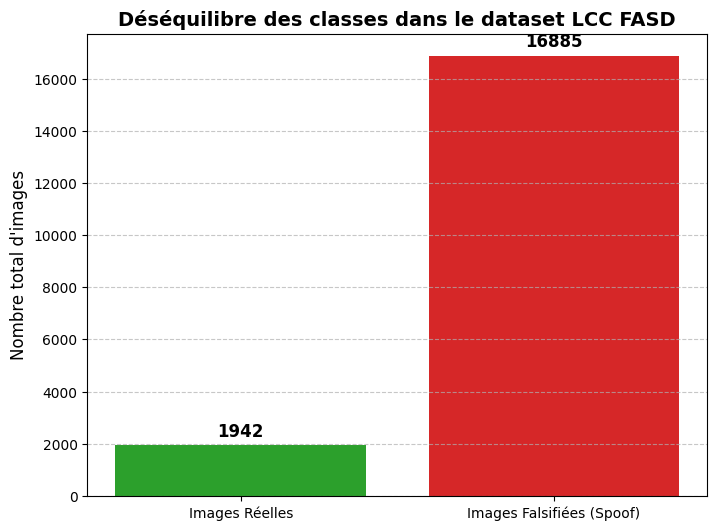

Graphique généré et sauvegardé sous le nom 'lcc_fasd_distribution.png' ! Vous pourrez le télécharger pour votre article.


In [7]:
import matplotlib.pyplot as plt


# Les données exactes de votre présentation LCC FASD
classes = ['Images Réelles', 'Images Falsifiées (Spoof)']
quantites = [1942, 16885] 

# Création du graphique
plt.figure(figsize=(8, 6))
# On utilise le vert pour les vraies images et le rouge pour les fausses,
# pour correspondre aux couleurs de votre diapositive "Workflow"
bars = plt.bar(classes, quantites, color=['#2ca02c', '#d62728'])

# Ajout des chiffres exacts au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 200, int(yval), 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Esthétique du graphique (titres, légendes)
plt.title('Déséquilibre des classes dans le dataset LCC FASD', fontsize=14, fontweight='bold')
plt.ylabel('Nombre total d\'images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Cette ligne sauvegarde l'image directement dans l'espace Kaggle !
plt.savefig('lcc_fasd_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

print("Graphique généré et sauvegardé sous le nom 'lcc_fasd_distribution.png' ! Vous pourrez le télécharger pour votre article.")

Chargement et configuration du Swin Transformer

In [ ]:
import torch.nn as nn
from torchvision.models import swin_t, Swin_T_Weights

print("--- Chargement et configuration du Swin Transformer ---")

# 1. Téléchargement du modèle pré-entraîné

weights = Swin_T_Weights.DEFAULT
model = swin_t(weights=weights)

# 2. Adaptation de la "Tête" de classification (Head)
in_features = model.head.in_features 

# On remplace l'ancienne couche par une nouvelle qui n'a que 2 sorties (Real, Spoof)
model.head = nn.Linear(in_features, 2)

# 3. Transfert du modèle sur le moteur de calcul (le GPU Tesla T4)
model = model.to(device)

print("✅ Modèle Swin Transformer chargé avec succès !")
print(f"La dernière couche a été modifiée pour prédire {model.head.out_features} classes.")

--- Chargement et configuration du Swin Transformer ---
✅ Modèle Swin Transformer chargé avec succès !
La dernière couche a été modifiée pour prédire 2 classes.


Configuration de l'entraînement

In [9]:
import torch.optim as optim

print("--- Configuration de l'entraînement ---")

# 1. Stratégie de Transfert : "Fine-tune all"
# On s'assure que tous les paramètres du modèle sont débloqués et peuvent apprendre
for param in model.parameters():
    param.requires_grad = True

# 2. Fonction de perte (Loss)
# CrossEntropyLoss est l'arbitre standard pour les problèmes de classification (Vrai vs Faux)
criterion = nn.CrossEntropyLoss()

# 3. L'Optimiseur
# On utilise Adam, un algorithme très performant. 
# lr = 0.0001 est le "Learning Rate" (la vitesse d'apprentissage). 
# S'il est trop grand, l'IA apprend trop vite et fait des erreurs. S'il est trop petit, c'est trop lent.
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("✅ Arbitre (Loss) et Entraîneur (Optimiseur) sont prêts !")
print("✅ Stratégie actuelle appliquée : Fine-tune all.")

--- Configuration de l'entraînement ---
✅ Arbitre (Loss) et Entraîneur (Optimiseur) sont prêts !
✅ Stratégie actuelle appliquée : Fine-tune all.


Démarrage de l'entraînement

In [10]:
import time
import torch

print("--- 🚀 Démarrage de l'entraînement (Stratégie : Fine-tune all) ---")

# Nombre de fois où le modèle va voir tout le dataset
num_epochs = 3 

# Listes pour garder une trace de l'évolution (utile pour faire des graphiques plus tard)
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    start_time = time.time()
    
    # ==========================================
    # 1. PHASE D'ENTRAÎNEMENT
    # ==========================================
    model.train() # On met le modèle en mode "apprentissage"
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        # On envoie les images et les étiquettes sur la carte graphique (GPU)
        images, labels = images.to(device), labels.to(device)
        
        # Remise à zéro de la mémoire de l'optimiseur
        optimizer.zero_grad()
        
        # L'IA fait sa prédiction sur les images
        outputs = model(images)
        
        # L'arbitre calcule l'erreur (Loss)
        loss = criterion(outputs, labels)
        
        # Rétropropagation : l'IA comprend ses erreurs et met à jour ses poids
        loss.backward()
        optimizer.step()
        
        # Calcul des statistiques en temps réel
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_accuracy = 100 * correct_train / total_train
    train_loss = running_loss / len(train_loader)
    
    # ==========================================
    # 2. PHASE DE VALIDATION
    # ==========================================
    model.eval() # On met le modèle en mode "examen" (il n'apprend plus)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # On bloque le calcul des gradients pour économiser la mémoire
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_accuracy = 100 * correct_val / total_val
    val_loss_final = val_loss / len(val_loader)
    
    # Sauvegarde de l'historique
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['val_loss'].append(val_loss_final)
    history['val_acc'].append(val_accuracy)
    
    epoch_time = time.time() - start_time
    
    # ==========================================
    # 3. AFFICHAGE DES RÉSULTATS DE L'ÉPOQUE
    # ==========================================
    print(f"Époque [{epoch+1}/{num_epochs}] terminée en {epoch_time:.0f} secondes")
    print(f"   📉 Train Loss: {train_loss:.4f} | 🎯 Train Acc: {train_accuracy:.2f}%")
    print(f"   📊 Val Loss:   {val_loss_final:.4f} | 🏆 Val Acc:   {val_accuracy:.2f}%")
    print("-" * 50)

print("🎉 Entraînement terminé avec succès !")

--- 🚀 Démarrage de l'entraînement (Stratégie : Fine-tune all) ---
Époque [1/3] terminée en 315 secondes
   📉 Train Loss: 0.1003 | 🎯 Train Acc: 95.79%
   📊 Val Loss:   0.1134 | 🏆 Val Acc:   96.03%
--------------------------------------------------
Époque [2/3] terminée en 292 secondes
   📉 Train Loss: 0.0168 | 🎯 Train Acc: 99.36%
   📊 Val Loss:   0.1701 | 🏆 Val Acc:   93.93%
--------------------------------------------------
Époque [3/3] terminée en 291 secondes
   📉 Train Loss: 0.0193 | 🎯 Train Acc: 99.33%
   📊 Val Loss:   0.1201 | 🏆 Val Acc:   97.29%
--------------------------------------------------
🎉 Entraînement terminé avec succès !


Évaluation finale du modèle sur le Test Set

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import torch

print("--- 📊 Évaluation finale du modèle sur le Test Set ---")

# On passe le modèle en mode évaluation (très important pour désactiver certains comportements d'entraînement)
model.eval()

# Listes pour stocker toutes les vraies étiquettes et toutes les prédictions
all_labels = []
all_preds = []

# On désactive le calcul du gradient car on n'apprend plus, on fait juste passer un test
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        # On stocke les résultats (on les ramène sur le CPU pour que scikit-learn puisse les lire)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# --- CALCUL DES MÉTRIQUES ---
# average='binary' par défaut, mais comme on a 2 classes (0: Real, 1: Spoof), on utilise 'macro' ou on précise la pos_label
# Souvent dans l'anti-spoofing, repérer l'attaque (Spoof) est la priorité. On va supposer ici que Spoof = 1.
accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average='macro') * 100
recall = recall_score(all_labels, all_preds, average='macro') * 100
f1 = f1_score(all_labels, all_preds, average='macro') * 100

print(f"✅ Exactitude (Accuracy) : {accuracy:.2f} %")
print(f"✅ Précision (Precision) : {precision:.2f} %")
print(f"✅ Rappel (Recall)       : {recall:.2f} %")
print(f"✅ F1-Score              : {f1:.2f} %")
print("-" * 50)

# Pour avoir un détail complet par classe (Vrai visage vs Faux visage)
print("\n--- Rapport de Classification détaillé ---")
# On récupère les noms des classes depuis le dataset (ex: ['real', 'spoof'])
class_names = train_dataset.classes
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

--- 📊 Évaluation finale du modèle sur le Test Set ---
✅ Exactitude (Accuracy) : 98.58 %
✅ Précision (Precision) : 92.66 %
✅ Rappel (Recall)       : 88.74 %
✅ F1-Score              : 90.60 %
--------------------------------------------------

--- Rapport de Classification détaillé ---
              precision    recall  f1-score   support

        real     0.8627    0.7803    0.8194       314
       spoof     0.9905    0.9946    0.9926      7266

    accuracy                         0.9858      7580
   macro avg     0.9266    0.8874    0.9060      7580
weighted avg     0.9852    0.9858    0.9854      7580



Lancement de l'Attaque Adversariale : FGSM

In [12]:
import torch
import torch.nn.functional as F

print("--- ⚔️ Lancement de l'Attaque Adversariale : FGSM ---")

# 1. Fonction qui crée l'image piégée
def fgsm_attack(image, epsilon, data_grad):
    # Récupérer la direction de l'erreur (le signe du gradient)
    sign_data_grad = data_grad.sign()
    
    # Créer l'image perturbée en ajoutant le bruit mathématique
    perturbed_image = image + epsilon * sign_data_grad
    
    return perturbed_image

# 2. Paramètre de l'attaque
# L'Epsilon représente la force du bruit. 
# 0.05 est un bruit très faible, généralement invisible à l'œil nu pour un humain.
epsilon = 0.05 
correct_fgsm = 0
total_fgsm = 0

model.eval() # Le modèle est en mode évaluation

print("Génération du bruit et attaque en cours, patientez quelques instants...")

# 3. Boucle de test sous attaque
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    
    # TRÈS IMPORTANT : On demande à PyTorch de calculer l'erreur par rapport aux IMAGES, 
    # et non plus par rapport aux poids du modèle comme pendant l'entraînement.
    images.requires_grad = True
    
    # Le modèle regarde l'image normale
    outputs = model(images)
    
    # On calcule son erreur
    loss = criterion(outputs, labels)
    model.zero_grad() # On efface les anciennes erreurs
    loss.backward()   # On calcule la nouvelle erreur
    
    # On récupère le fameux gradient (la faille mathématique de l'image)
    data_grad = images.grad.data
    
    # On crée l'image piégée !
    perturbed_images = fgsm_attack(images, epsilon, data_grad)
    
    # On repasse l'image piégée dans le modèle pour voir s'il se fait avoir
    outputs_fgsm = model(perturbed_images)
    _, final_pred = torch.max(outputs_fgsm.data, 1)
    
    # On compte combien de fois le modèle a eu raison MALGRÉ l'attaque
    total_fgsm += labels.size(0)
    correct_fgsm += (final_pred == labels).sum().item()

# 4. Calcul du score final sous attaque
fgsm_accuracy = 100 * correct_fgsm / total_fgsm

print("\n--- 💥 RÉSULTATS DE L'ATTAQUE ---")
print(f"Force du bruit (Epsilon) : {epsilon}")
print(f"✅ Exactitude normale (sans attaque) : {accuracy:.2f} %") # 'accuracy' vient de la Cellule 9
print(f"❌ Exactitude sous attaque FGSM  : {fgsm_accuracy:.2f} %")
print(f"📉 Chute de performance          : {(accuracy - fgsm_accuracy):.2f} %")

--- ⚔️ Lancement de l'Attaque Adversariale : FGSM ---
Génération du bruit et attaque en cours, patientez quelques instants...

--- 💥 RÉSULTATS DE L'ATTAQUE ---
Force du bruit (Epsilon) : 0.05
✅ Exactitude normale (sans attaque) : 98.58 %
❌ Exactitude sous attaque FGSM  : 56.98 %
📉 Chute de performance          : 41.60 %


Lancement de l'Attaque Adversariale : PGD

In [13]:
import torch

print("--- ☠️ Lancement de l'Attaque Adversariale : PGD ---")

# Paramètres de l'attaque PGD
epsilon = 0.05      # La force maximale du bruit autorisé
alpha = 0.01        # La force du pas à chaque itération
iters = 10          # Le nombre de fois que l'on répète l'attaque sur l'image

def pgd_attack(model, images, labels, epsilon, alpha, iters):
    # On garde une copie de l'image originale
    original_images = images.clone().detach()
    perturbed_images = images.clone().detach()
    
    # Boucle itérative du PGD
    for i in range(iters):
        perturbed_images.requires_grad = True
        
        # Le modèle regarde l'image (en cours de piratage)
        outputs = model(perturbed_images)
        model.zero_grad()
        loss = criterion(outputs, labels)
        loss.backward()
        
        # On ajoute un petit pas de bruit (alpha)
        adv_images = perturbed_images + alpha * perturbed_images.grad.sign()
        
        # "Projection" : On s'assure que le bruit total ne dépasse jamais l'epsilon autorisé
        eta = torch.clamp(adv_images - original_images, min=-epsilon, max=epsilon)
        
        # On met à jour l'image piégée
        perturbed_images = torch.clamp(original_images + eta, min=original_images.min(), max=original_images.max()).detach()
        
    return perturbed_images

# --- Lancement de l'évaluation ---
correct_pgd = 0
total_pgd = 0

model.eval()
print(f"Génération de l'attaque itérative PGD ({iters} étapes), patientez...")

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    
    # Création des images piégées avec PGD
    perturbed_images = pgd_attack(model, images, labels, epsilon, alpha, iters)
    
    # Test du modèle face à ces images
    outputs_pgd = model(perturbed_images)
    _, final_pred = torch.max(outputs_pgd.data, 1)
    
    total_pgd += labels.size(0)
    correct_pgd += (final_pred == labels).sum().item()

# Calcul du score final
pgd_accuracy = 100 * correct_pgd / total_pgd

print("\n--- 🧨 RÉSULTATS DE L'ATTAQUE PGD ---")
print(f"Force max (Epsilon) : {epsilon} | Étapes : {iters}")
print(f"✅ Exactitude normale (sans attaque) : {accuracy:.2f} %")
print(f"❌ Exactitude sous attaque FGSM  : {fgsm_accuracy:.2f} %")
print(f"💀 Exactitude sous attaque PGD   : {pgd_accuracy:.2f} %")
print("-" * 50)

--- ☠️ Lancement de l'Attaque Adversariale : PGD ---
Génération de l'attaque itérative PGD (10 étapes), patientez...

--- 🧨 RÉSULTATS DE L'ATTAQUE PGD ---
Force max (Epsilon) : 0.05 | Étapes : 10
✅ Exactitude normale (sans attaque) : 98.58 %
❌ Exactitude sous attaque FGSM  : 56.98 %
💀 Exactitude sous attaque PGD   : 0.00 %
--------------------------------------------------


Génération des graphiques de résultats (Fine-tune all)

--- 📊 Génération des graphiques de résultats (Fine-tune all) ---


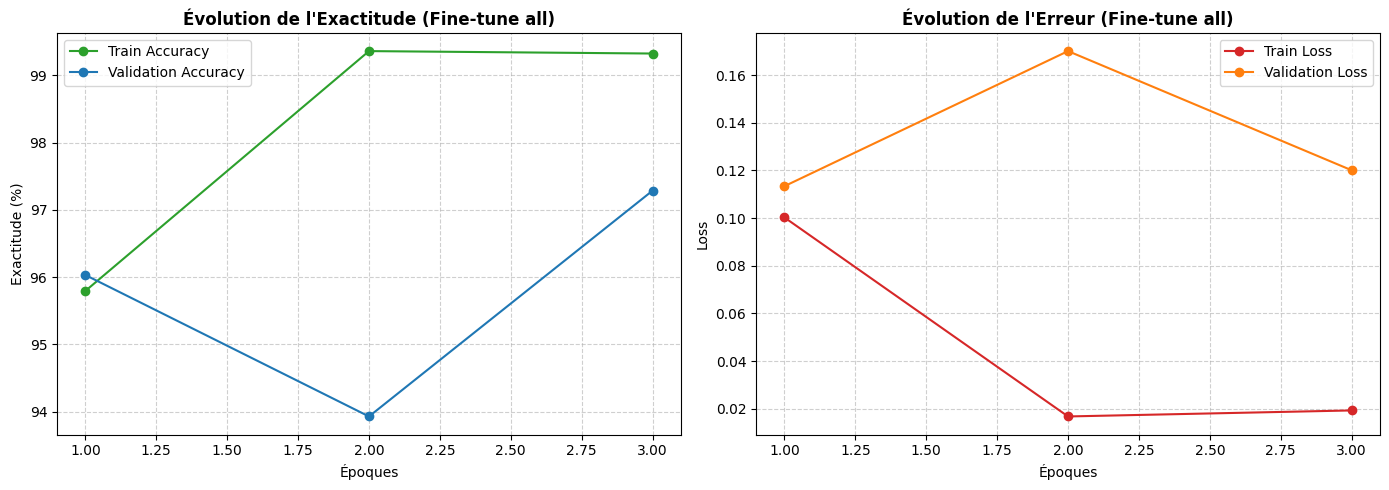

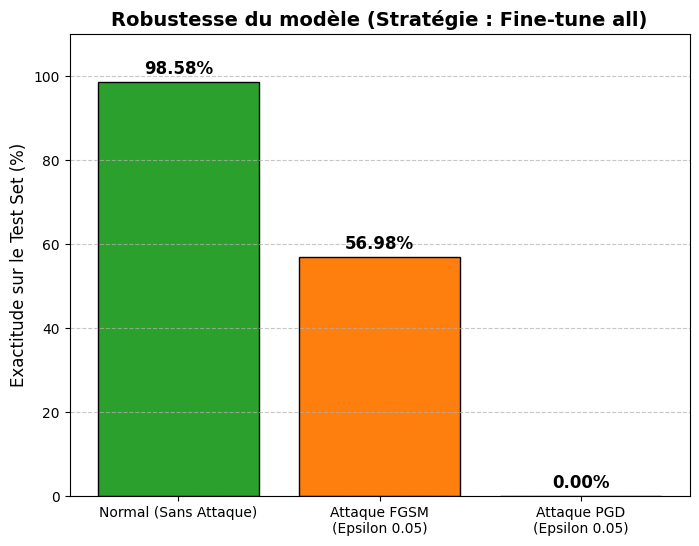

✅ Graphiques générés et sauvegardés sous les noms 'learning_curves_finetune.png' et 'robustness_finetune_all.png'.


In [14]:
import matplotlib.pyplot as plt
import numpy as np

print("--- 📊 Génération des graphiques de résultats (Fine-tune all) ---")

# ==========================================
# FIGURE 1 : Courbes d'apprentissage (Learning Curves)
# ==========================================
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Sous-graphique 1 : L'évolution de l'Exactitude (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o', color='#2ca02c')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o', color='#1f77b4')
plt.title('Évolution de l\'Exactitude (Fine-tune all)', fontsize=12, fontweight='bold')
plt.xlabel('Époques')
plt.ylabel('Exactitude (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Sous-graphique 2 : L'évolution de l'Erreur (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', color='#d62728')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o', color='#ff7f0e')
plt.title('Évolution de l\'Erreur (Fine-tune all)', fontsize=12, fontweight='bold')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('learning_curves_finetune.png', dpi=300)
plt.show()

# ==========================================
# FIGURE 2 : Robustesse face aux attaques
# ==========================================
plt.figure(figsize=(8, 6))

# On rassemble vos scores finaux
conditions = ['Normal (Sans Attaque)', 'Attaque FGSM\n(Epsilon 0.05)', 'Attaque PGD\n(Epsilon 0.05)']
scores = [accuracy, fgsm_accuracy, pgd_accuracy] # Variables calculées dans vos cellules précédentes
couleurs = ['#2ca02c', '#ff7f0e', '#d62728']

bars = plt.bar(conditions, scores, color=couleurs, edgecolor='black')

# Ajout des pourcentages au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Robustesse du modèle (Stratégie : Fine-tune all)', fontsize=14, fontweight='bold')
plt.ylabel('Exactitude sur le Test Set (%)', fontsize=12)
plt.ylim(0, 110) # Pour laisser de la place au texte au-dessus de la barre de 98%
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('robustness_finetune_all.png', dpi=300)
plt.show()

print("✅ Graphiques générés et sauvegardés sous les noms 'learning_curves_finetune.png' et 'robustness_finetune_all.png'.")